In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset

import numpy as np

from matplotlib import pyplot as plt
from scipy.stats import gaussian_kde

import os
import glob
import tqdm
from typing import List, Iterator, Tuple, Optional, Union

from utils import *
from optimus import *

device = torch.device('cuda:0')

In [ ]:
counter = KmerCounter(k=3, device=device)

#Read data and merge
max_pad_len = 100 #Will be input sequence length into model
data_dict = {}

#To cutoff by minimum quantile of RL
def cutoff(seq, rl, tr, kmers, quantile_cutoff, tr_cutoff=None):
    if tr_cutoff is None:
        if quantile_cutoff > 0.0:
            seq = seq[tr>tr.quantile(quantile_cutoff)]
            rl = rl[tr>tr.quantile(quantile_cutoff)]
            kmers = kmers[tr>tr.quantile(quantile_cutoff)]
            tr = tr[tr>tr.quantile(quantile_cutoff)]
    else:
        seq = seq[tr>=tr_cutoff]
        rl = rl[tr>=tr_cutoff]
        kmers = kmers[tr>tr_cutoff]
        tr = tr[tr>=tr_cutoff]
        
    seq = seq[~torch.isnan(rl)]
    tr = tr[~torch.isnan(rl)]
    kmers = kmers[~torch.isnan(rl)]
    rl = rl[~torch.isnan(rl)]

    seq = seq[~torch.isinf(rl)]
    tr = tr[~torch.isinf(rl)]
    kmers = kmers[~torch.isinf(rl)]
    rl = rl[~torch.isinf(rl)]

    trs = tr / tr.sum()
    srl = scaler(rl)
    qrl = quantile_normalize_binned(rl, tr.log10(), 10)
    sqrl = scaler(qrl)
    return seq, rl, tr, trs, qrl, srl, sqrl, kmers

for i, csv_file in enumerate(glob.glob("*.csv.gz")):
    name = csv_file.split("_")[1:3]
    if name[0] == "egfp" and name[1] == "unmod":
        name = "egfp_unmod"
        quantile_cutoff = 0.2
    elif name[0] == "egfp" and name[1] == "pseudo":
        name = "egfp_pseudo"
        quantile_cutoff = 0.2
    elif name[0] == "egfp" and name[1] == "m1pseudo":
        name = "egfp_m1pseudo"
        quantile_cutoff = 0.2        
    elif name[0] == "mcherry":
        name = "mcherry_unmod"
        quantile_cutoff = 0.2
    elif name[0] == "designed":
        name = "egfp_unmod"
        quantile_cutoff = 0.0
    elif name[0] == "varying":
        name = "egfp_unmod"
        quantile_cutoff = 0.05

    df = pd.read_csv(csv_file)
    seq = dna_to_onehot([s.upper() for s in df['utr'].tolist()], max_pad_len=max_pad_len).transpose(1, 2)
    rl = torch.tensor(df['rl']).to(torch.float32)
    kmers = counter.count_kmers(seq.to(device), exclude_n=False)[:,~counter.n_mask].cpu().to(torch.float32)
    if 'total_reads' in df.columns:
        tr = torch.tensor(df['total_reads']).to(torch.float32)
    else:
        tr = torch.tensor(df['total']).to(torch.float32)

    data_cut = cutoff(seq, rl, tr, kmers, quantile_cutoff)

    if name in data_dict:
        data_dict[name] = [ torch.cat([data_cut[i], data_dict[name][i]]) for i in range(8) ]
    else:
        data_dict[name] = data_cut

    del df, seq, rl, kmers

#Deduplicate
for k, v in data_dict.items():
    selected_inds = select_onehot_by_priority(v[0].to(device), v[3].to(device), select_mode='max')
    data_dict[k] = [ v[i][selected_inds.to(v[i].device)] for i in range(8) ]
    

In [ ]:
#Split data, stratified by length and using higher reads for valid/test set
test_prop = 0.15
val_prop = 0.15

test_datasets_dict = {}
val_datasets_dict = {}
train_datasets_dict = {}

for name, [ seq, rl, tr, trs, qrl, srl, sqrl, kmers ] in data_dict.items():
    print(name)
    if name == 'egfp_unmod': #Valid/test only on egfp_unmod
        [ train_seq, train_rl, train_srl, train_tr, train_kmer], [ _seq, _rl, _srl, _tr, _kmer ] = stratified_split(seq, sqrl, trs, kmers, fraction=test_prop+val_prop, rand_split=False)
        [ val_seq, val_rl, val_srl, val_tr, val_kmer ], [ test_seq, test_rl, test_srl, test_tr, test_kmer ] = stratified_split(_seq, _rl, _tr, _kmer, fraction=test_prop/(test_prop+val_prop), rand_split=False)
        del kmers, _seq, _rl, _srl, _tr, _kmer
        
        train_datasets_dict[name] = TensorDataset(train_seq, train_srl, train_tr, train_kmer)
        val_datasets_dict[name] = TensorDataset(val_seq, val_srl, val_tr, val_kmer)
        test_datasets_dict[name] = TensorDataset(test_seq, test_srl, test_tr, test_kmer)
    else:
        train_datasets_dict[name] = TensorDataset(seq, sqrl, trs, kmers)

In [ ]:
#Filter out valid/test seqs with close k-mer distance to training set
dist_cutoff = 0.35
chunk_size = 1000

for k, v in val_datasets_dict.items():
    val_dists = euc_distance_min(v.tensors[3].to(device), torch.cat([ v.tensors[3] for k, v in train_datasets_dict.items() ]).to(device), chunk_size)
    train_datasets_dict[k] = TensorDataset(*[ torch.cat([v.tensors[i][(val_dists<dist_cutoff).to(v.tensors[i].device)], train_datasets_dict[k].tensors[i]]) for i in range(len(v.tensors)) ])
    val_datasets_dict[k] = TensorDataset(*[ t[(val_dists>=dist_cutoff).to(t.device)] for t in v.tensors ])    

for k, v in test_datasets_dict.items():
    test_dists = euc_distance_min(v.tensors[3].to(device), torch.cat([ v.tensors[3] for k, v in train_datasets_dict.items() ]).to(device), chunk_size)
    train_datasets_dict[k] = TensorDataset(*[ torch.cat([v.tensors[i][(test_dists<dist_cutoff).to(v.tensors[i].device)], train_datasets_dict[k].tensors[i]]) for i in range(len(v.tensors)) ])
    test_datasets_dict[k] = TensorDataset(*[ t[(test_dists>=dist_cutoff).to(t.device)] for t in v.tensors ])
    

In [11]:
train_datasets_dict, val_datasets_dict, test_datasets_dict = torch.load("datasets_dict_dedup_filter.pth", weights_only=False)

In [14]:
model_mrl = Optimus(
    inp_len=100, 
    nbr_filters=120, filter_len=8, border_mode='same', 
    dropout1=0.0, dropout2=0.0, dropout3=0.2, 
    nodes=40, 
    out_kw=['egfp_unmod','egfp_pseudo','egfp_m1pseudo','mcherry_unmod'], n_out_col=1)
model_mrl = model_mrl.to(device)

In [15]:
#Train model
criterion = nn.MSELoss() # MSE loss function for regression

optimizer = torch.optim.AdamW(
    model_mrl.parameters(),
    lr=0.001,
    betas=(0.9, 0.999),
    weight_decay=0.01
)

num_epochs = 10
batch_size = 128

train_sampler = ProportionalMultiDatasetSampler([ v for k, v in train_datasets_dict.items() ], batch_size, shuffle=True)
val_sampler = ProportionalMultiDatasetSampler([ v for k, v in val_datasets_dict.items() ], batch_size, shuffle=False)

# Training history
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training phase
    model_mrl.train()
    train_loss = 0.0
    num_train_batches = 0
    for [ data, scaled_targets, _, _ ], dataset_idx in tqdm.tqdm(train_sampler):
        data, scaled_targets = data.to(device), scaled_targets.to(device)
        optimizer.zero_grad()
        outputs = model_mrl(data, final_ind=dataset_idx).squeeze(1)
        loss = criterion(outputs, scaled_targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_mrl.parameters(), max_norm=0.5)
        optimizer.step()
        train_loss += loss.item()
        num_train_batches += 1
    
    # Validation phase
    model_mrl.eval()
    val_loss = 0.0
    num_val_batches = 0
    with torch.inference_mode():
        for [ data, scaled_targets, _, _ ], dataset_idx in tqdm.tqdm(val_sampler):
            data, scaled_targets = data.to(device), scaled_targets.to(device)
            outputs = model_mrl(data, final_ind=dataset_idx).squeeze(1)
            loss = criterion(outputs, scaled_targets)
            val_loss += loss.item()
            num_val_batches += 1

    avg_train_loss = train_loss / num_train_batches
    avg_val_loss = val_loss / num_val_batches    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    print(f'  Epoch {epoch+1}/{num_epochs}: Train Loss: {avg_train_loss:.6f}, '
          f'Val Loss: {avg_val_loss:.6f}')
    
    if val_losses[-1] == np.min(val_losses):
        print('saving')
        model_path = os.path.join("./", f'optimus_mrl_multi.pth')
        torch.save({
            'model_state_dict': model_mrl.state_dict(),
            'final_train_loss': train_losses[-1],
            'final_val_loss': val_losses[-1],
        }, model_path)        

13635it [01:25, 160.04it/s]
169it [00:00, 429.74it/s]


  Epoch 1/10: Train Loss: 0.379050, Val Loss: 0.280092
saving


13635it [01:25, 159.94it/s]
169it [00:00, 434.08it/s]


  Epoch 2/10: Train Loss: 0.324921, Val Loss: 0.206335
saving


13635it [01:25, 159.89it/s]
169it [00:00, 432.47it/s]


...

  Epoch 8/10: Train Loss: 0.277748, Val Loss: 0.204947


13635it [01:25, 159.79it/s]
169it [00:00, 433.42it/s]


  Epoch 9/10: Train Loss: 0.274667, Val Loss: 0.221242


13635it [01:25, 159.84it/s]
169it [00:00, 432.93it/s]

  Epoch 10/10: Train Loss: 0.272542, Val Loss: 0.215822


In [16]:
#Test
test_sampler = ProportionalMultiDatasetSampler([ v for k, v in test_datasets_dict.items() ], batch_size, shuffle=False)
model_mrl.load_state_dict(torch.load("optimus_mrl_multi.pth")['model_state_dict']) #Best valid weights

all_targets = []
all_preds = []
all_lens = []
test_loss = 0.0
num_test_batches = 0
with torch.inference_mode():
    for [ data, scaled_targets, _, _ ], dataset_idx in tqdm.tqdm(test_sampler):
        if dataset_idx == 0:
            data, scaled_targets = data.to(device), scaled_targets.to(device)
            outputs = model_mrl(data, final_ind=dataset_idx).squeeze(1)
            loss = criterion(outputs, scaled_targets)
            test_loss += loss.item()
            num_test_batches += 1
            all_targets += [ scaled_targets ] 
            all_preds += [ outputs.clone() ]
            all_lens += [ data.sum([1, 2]) ]

all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)
all_lens = torch.cat(all_lens)

242it [00:00, 416.75it/s]


tensor(25., device='cuda:0') tensor(45., device='cuda:0') 0.9204870232917509
tensor(45., device='cuda:0') tensor(65., device='cuda:0') 0.9245197900014915
tensor(65., device='cuda:0') tensor(85., device='cuda:0') 0.9099181562978705
tensor(85., device='cuda:0') tensor(100., device='cuda:0') 0.8862058559812523


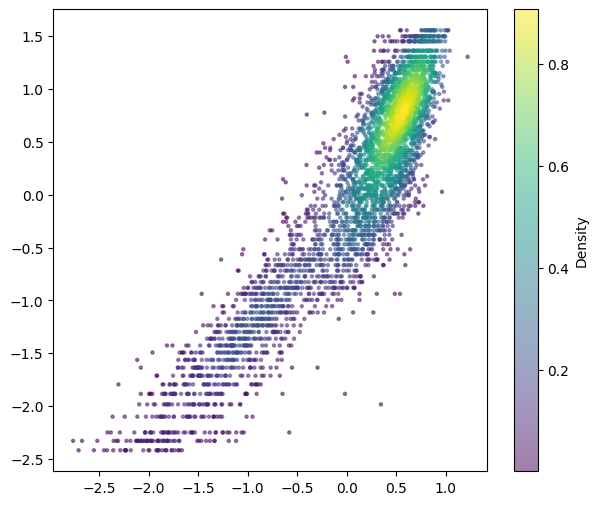

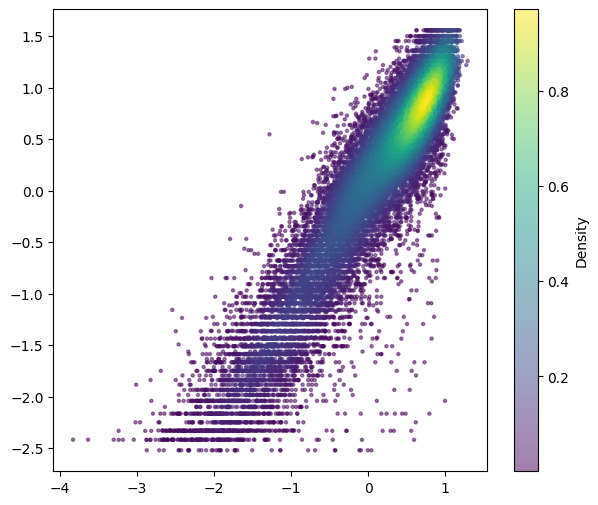

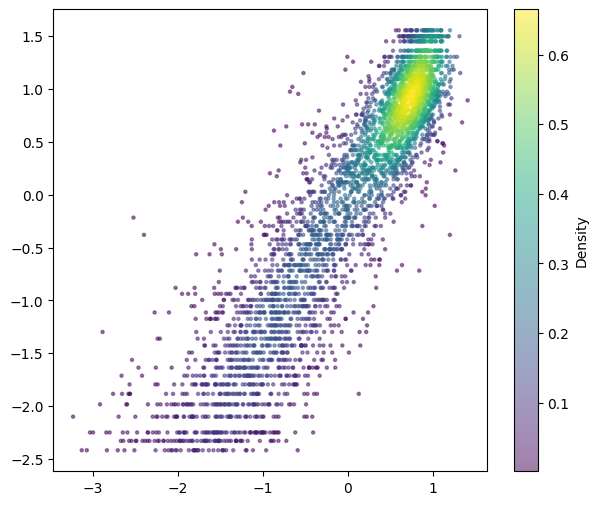

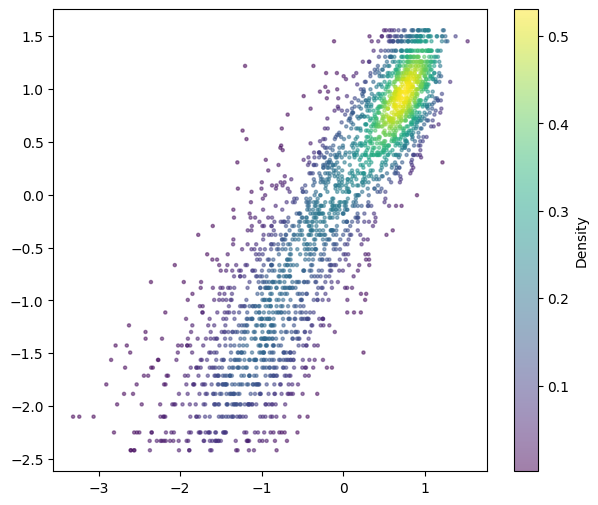

In [17]:
#Check r2
bins = torch.arange(all_lens.min(), all_lens.max(), 20)
bins = torch.cat([bins.to(device), all_lens.max().unsqueeze(0)])
for i in range(bins.shape[0]-1):
    used = (all_lens>=bins[i])&(all_lens<bins[i+1])
    r2 = np.corrcoef(all_preds[used].cpu(), all_targets[used].cpu())[0, 1]
    print(bins[i], bins[i+1], r2)
    
    lens = all_lens[used].cpu()
    x = all_preds[used].cpu()
    y = all_targets[used].cpu()
    
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    density = kde(xy)
    
    fig, ax2 = plt.subplots(1, 1, figsize=(7, 6))
    scatter = ax2.scatter(x, y, c=density, cmap='viridis', s=5, edgecolors=None, alpha=0.5)
    
    plt.colorbar(scatter, ax=ax2, label='Density')